In [94]:
import pandas as pd

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the 3 separate raw CSV datasets
customers = pd.read_csv("../data/raw/customers.csv")
transactions = pd.read_csv("../data/raw/transactions.csv")
orders = pd.read_csv("../data/raw/orders.csv")

print("CSV Ingestion complete. Initial data shapes:")
print(f"Customers: {customers.shape} | Transactions: {transactions.shape} | Orders: {orders.shape}")

In [96]:
customers

,customer_id,customer_name,email,phone_primary,phone_secondary,city,country,created_date,purchase_amount
0,C001,John Smith,john.smith@email.com,555-0101,NaN,Boston,USA,2024-01-15,52.00
1,C001,John Smith,john.smith@email.com,555-0101,NaN,Boston,USA,2024-03-22,52.00
2,C002,Sarah Khan,sarah@company.com,555-0202,555-9999,Austin,usa,2024-02-10,58.00
3,C002,Sarah K.,sarah.k@company.com,555-0202,555-9999,Austin,United States,2024-02-11,58.00
4,C003,Wei Zhang,wei.zhang@corp.io,NaN,555-0303,Seattle,US,2024-01-20,89.99
5,C004,Maria Garcia,maria@example.net,555-0404,NaN,NaN,U.S.A.,2024-03-05,42.80
6,C005,Liam O'Brien,liam@test.co,NaN,NaN,Denver,UK,2024-01-08,34.50
7,C005,Liam O'Brien,liam@test.co,NaN,NaN,Denver,UK,2024-02-14,34.50
8,C006,Priya Patel,priya.p@biz.com,555-0606,555-1111,NaN,United Kingdom,2024-04-01,310.99
9,C007,James Wilson,NaN,555-0707,NaN,Chicago,Great Britain,2024-02-28,47.00


In [97]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      20 non-null     object        
 1   customer_name    20 non-null     object        
 2   email            18 non-null     object        
 3   phone_primary    14 non-null     object        
 4   phone_secondary  9 non-null      object        
 5   city             15 non-null     object        
 6   country          20 non-null     object        
 7   created_date     20 non-null     datetime64[ns]
 8   purchase_amount  20 non-null     float64       
dtypes: datetime64[ns](1), float64(1), object(7)
memory usage: 1.5+ KB


In [98]:
check_duplicates = customers[customers.duplicated(subset =['customer_id'], keep=False)]
print(check_duplicates)

   customer_id     customer_name                 email phone_primary  \
0         C001        John Smith  john.smith@email.com      555-0101   
1         C001        John Smith  john.smith@email.com      555-0101   
2         C002        Sarah Khan     sarah@company.com      555-0202   
3         C002          Sarah K.   sarah.k@company.com      555-0202   
6         C005      Liam O'Brien          liam@test.co           NaN   
7         C005      Liam O'Brien          liam@test.co           NaN   
12        C010  Fatima Al-Hassan         fatima@uae.ae      555-1010   
13        C010  Fatima Al-Hassan         fatima@uae.ae      555-1010   

   phone_secondary    city               country created_date  purchase_amount  
0              NaN  Boston                   USA   2024-01-15            52.00  
1              NaN  Boston                   USA   2024-03-22            52.00  
2         555-9999  Austin                   usa   2024-02-10            58.00  
3         555-9999  Austin 

In [99]:
customers['country']

0                      USA
1                      USA
2                      usa
3            United States
4                       US
5                   U.S.A.
6                       UK
7                       UK
8           United Kingdom
9            Great Britain
10                 Germany
11                  Mexico
12                     UAE
13    United Arab Emirates
14                      UK
15                   Japan
16          united kingdom
17                      US
18                  Canada
19           UNITED STATES
Name: country, dtype: object

In [100]:
customers['country'].unique()

array(['USA', 'usa', 'United States', 'US', 'U.S.A.', 'UK',
       'United Kingdom', 'Great Britain', 'Germany', 'Mexico', 'UAE',
       'United Arab Emirates', 'Japan', 'united kingdom', 'Canada',
       'UNITED STATES'], dtype=object)

In [101]:
for cust_id, group in customers.groupby('customer_id'):
    print(f"---group:{cust_id}---")
    print(group)
    print() 

---group:C001---
  customer_id customer_name                 email phone_primary  \
0        C001    John Smith  john.smith@email.com      555-0101   
1        C001    John Smith  john.smith@email.com      555-0101   

  phone_secondary    city country created_date  purchase_amount  
0             NaN  Boston     USA   2024-01-15             52.0  
1             NaN  Boston     USA   2024-03-22             52.0  

---group:C002---
  customer_id customer_name                email phone_primary  \
2        C002    Sarah Khan    sarah@company.com      555-0202   
3        C002      Sarah K.  sarah.k@company.com      555-0202   

  phone_secondary    city        country created_date  purchase_amount  
2        555-9999  Austin            usa   2024-02-10             58.0  
3        555-9999  Austin  United States   2024-02-11             58.0  

---group:C003---
  customer_id customer_name              email phone_primary phone_secondary  \
4        C003     Wei Zhang  wei.zhang@corp.io   

In [102]:
def first_valid(series):
    for val in series:
        if pd.notna(val):
            return val
    return None

In [103]:
merged = customers.groupby ('customer_id', as_index = False).agg(first_valid)
print(merged)

   customer_id     customer_name                 email phone_primary  \
0         C001        John Smith  john.smith@email.com      555-0101   
1         C002        Sarah Khan     sarah@company.com      555-0202   
2         C003         Wei Zhang     wei.zhang@corp.io          None   
3         C004      Maria Garcia     maria@example.net      555-0404   
4         C005      Liam O'Brien          liam@test.co          None   
5         C006       Priya Patel       priya.p@biz.com      555-0606   
6         C007      James Wilson                  None      555-0707   
7         C008       Anna Müller        anna@europe.de          None   
8         C009     Carlos Rivera          carlos@mx.co      555-0909   
9         C010  Fatima Al-Hassan         fatima@uae.ae      555-1010   
10        C011         Tom Baker   tom.baker@email.com      555-1111   
11        C012       Yuki Tanaka                  None          None   
12        C013        Emma Brown    emma.b@outlook.com      555-

In [104]:
transactions

,transaction_id,customer_id,purchase_amount,transaction_date
0,T1001,C001,52.00,2024-01-16
1,T1002,C003,89.99,2024-01-21
2,T1003,C005,34.50,2024-01-09
3,T1004,C008,120.00,2024-01-31
4,T1005,C009,67.25,2024-03-19
5,T1006,C015,210.00,2024-01-26
6,T1007,C001,75.00,2024-03-23
7,T1008,C004,42.80,2024-03-06
8,T1009,C011,95.00,2024-01-13
9,T1010,C012,180.50,2024-03-26


In [105]:
orders

,order_id,customer_id,email,order_date,ship_date,quantity,unit_price,total_amount
0,O1001,C001,john.smith@email.com,2024-01-16,2024-01-18,2,26.00,52.00
1,O1002,C003,wei.zhang@corp.io,2024-01-21,2024-01-24,1,89.99,89.99
2,O1003,C008,anna@europe.de,2024-01-31,2024-02-03,3,40.00,120.00
3,O1004,C015,olivia.lee@corp.com,2024-01-26,2024-01-29,1,210.00,210.00
4,O1005,C011,tom.baker@email.com,2024-01-13,2024-01-15,5,19.00,95.00
5,O2001,C004,maria@example.net,2026-06-01,2026-06-04,1,42.80,42.80
6,O2002,C016,ethan.c@mail.com,2026-12-25,2026-12-28,2,72.50,145.00
7,O2003,C009,carlos@mx.co,2025-11-30,2025-12-02,1,67.25,67.25
8,O3001,C002,sarah@company.com,2024-02-11,2024-02-09,2,29.00,58.00
9,O3002,C006,priya.p@biz.com,2024-04-02,2024-03-30,3,103.66,310.99


In [106]:
# store each table with its unique id column
tables = {
    'customers'    : (customers,    'customer_id'),
    'transactions' : (transactions, 'transaction_id'),
    'orders'       : (orders,       'order_id'),
}

for name, (df, id_col) in tables.items():
    cleaned    = df.drop_duplicates(subset=[id_col], keep='first')
    dropped    = len(df) - len(cleaned)
    remaining  = cleaned.duplicated(subset=[id_col]).sum()

    print(f'--- {name} ---')
    print(f'Original rows        : {len(df)}')
    print(f'Cleaned rows         : {len(cleaned)}')
    print(f'Rows dropped         : {dropped}')
    print(f'Remaining duplicates : {remaining}')
    print()

--- customers ---
Original rows        : 20
Cleaned rows         : 16
Rows dropped         : 4
Remaining duplicates : 0

--- transactions ---
Original rows        : 23
Cleaned rows         : 23
Rows dropped         : 0
Remaining duplicates : 0

--- orders ---
Original rows        : 52
Cleaned rows         : 52
Rows dropped         : 0
Remaining duplicates : 0



In [107]:
# run ALL of this together in one cell 

cleaned_tables = {}   # ← must be here!

tables = {
    'customers'    : (customers,    'customer_id'),
    'transactions' : (transactions, 'transaction_id'),
    'orders'       : (orders,       'order_id'),
}

for name, (df, id_col) in tables.items():
    cleaned_tables[name] = df.drop_duplicates(subset=[id_col], keep='first')
    dropped   = len(df) - len(cleaned_tables[name])
    remaining = cleaned_tables[name].duplicated(subset=[id_col]).sum()

    print(f'--- {name} ---')
    print(f'Original rows        : {len(df)}')
    print(f'Cleaned rows         : {len(cleaned_tables[name])}')
    print(f'Rows dropped         : {dropped}')
    print(f'Remaining duplicates : {remaining}')
    print()

# now access cleaned tables
customers_cleaned    = cleaned_tables['customers']
transactions_cleaned = cleaned_tables['transactions']
orders_cleaned       = cleaned_tables['orders']

print('All tables cleaned and saved!')

--- customers ---
Original rows        : 20
Cleaned rows         : 16
Rows dropped         : 4
Remaining duplicates : 0

--- transactions ---
Original rows        : 23
Cleaned rows         : 23
Rows dropped         : 0
Remaining duplicates : 0

--- orders ---
Original rows        : 52
Cleaned rows         : 52
Rows dropped         : 0
Remaining duplicates : 0

All tables cleaned and saved!


In [108]:
for name, df in cleaned_tables.items():
    print(f'---{name}---')
    print(df.isnull().sum())
    print()

---customers---
customer_id        0
customer_name      0
email              2
phone_primary      5
phone_secondary    9
city               5
country            0
created_date       0
purchase_amount    0
dtype: int64

---transactions---
transaction_id      0
customer_id         0
purchase_amount     0
transaction_date    0
dtype: int64

---orders---
order_id        0
customer_id     0
email           2
order_date      0
ship_date       0
quantity        0
unit_price      0
total_amount    0
dtype: int64



In [109]:
customers_cleaned = cleaned_tables['customers'].copy()

#emails cannot guess
missing_emails = customers_cleaned[customers_cleaned['email'].isna()]
print('customers with missing emails:')
print(missing_emails[['customer_id', 'customer_name']])

customers_cleaned['email'] = customers_cleaned['email'].fillna('Not Provided')
print('--- nulls are filled')

#phone numbers cannot guess
customers_cleaned['phone_primary'] = customers_cleaned['phone_primary'].fillna('Not Provided')
customers_cleaned['phone_secondary'] = customers_cleaned['phone_secondary'].fillna('Not Provided')

#fixing na in City
customers_cleaned['city'] = customers_cleaned['city'].fillna('Unknown')

customers with missing emails:
   customer_id customer_name
9         C007  James Wilson
15        C012   Yuki Tanaka
--- nulls are filled


In [110]:
#orders missing values
orders_cleaned = cleaned_tables['orders'].copy()

missing_emails = orders_cleaned[orders_cleaned['email'].isna()]
print('Orders email missing')
print(missing_emails[['customer_id', 'order_id']])

orders_cleaned['email'] = orders_cleaned['email'].fillna('Not Provided')
print('--- nulls are filled ---')
print(orders_cleaned['email'].isnull().sum())

Orders email missing
   customer_id order_id
12        C012    O3005
16        C007    O3009
--- nulls are filled ---
0


In [111]:
for name, df in [('customers', customers_cleaned),
                 ('orders', orders_cleaned),
                 ('transactions', transactions_cleaned)]:
    print(f'--- {name} -----')
    missing = df.isnull().sum()
    print(missing[missing>0] if missing.any() else 'No missing values')
    print()


--- customers -----
No missing values

--- orders -----
No missing values

--- transactions -----
No missing values



In [112]:
customers_cleaned['country'].unique()

array(['USA', 'usa', 'US', 'U.S.A.', 'UK', 'United Kingdom',
       'Great Britain', 'Germany', 'Mexico', 'UAE', 'Japan',
       'united kingdom', 'Canada', 'UNITED STATES'], dtype=object)

In [113]:
country_map ={
    'United States' : 'USA',
    'United Kingdom' : "UK",
    'Great Britain' : 'UK',
    'United States' : 'USA',
    'U.S.A.': 'USA',
    'united kingdom' : 'UK',
    'usa' : 'USA',
    'US' : 'USA',
    'UNITED STATES': 'USA'

}

customers_cleaned['country'] = customers_cleaned['country'].replace(country_map)

print(customers_cleaned['country'].unique())

['USA' 'UK' 'Germany' 'Mexico' 'UAE' 'Japan' 'Canada']


In [114]:
for name, df in [('customers', customers_cleaned),
                 ('transactions', transactions_cleaned),
                 ('orders', orders_cleaned)]:
    print ('----- {name}----')
    print(f'Rows        : {len(df)}')
    print(f'nulls       : {df.isnull().sum()}')
    print(f'Dupicates   : {df.duplicated().sum()}')

    print()

----- {name}----
Rows        : 16
nulls       : customer_id        0
customer_name      0
email              0
phone_primary      0
phone_secondary    0
city               0
country            0
created_date       0
purchase_amount    0
dtype: int64
Dupicates   : 0

----- {name}----
Rows        : 23
nulls       : transaction_id      0
customer_id         0
purchase_amount     0
transaction_date    0
dtype: int64
Dupicates   : 0

----- {name}----
Rows        : 52
nulls       : order_id        0
customer_id     0
email           0
order_date      0
ship_date       0
quantity        0
unit_price      0
total_amount    0
dtype: int64
Dupicates   : 0



In [115]:
# recreate everything fresh from cleaned_tables
customers_cleaned = cleaned_tables['customers'].copy()
orders_cleaned = cleaned_tables['orders'].copy()
transactions_cleaned = cleaned_tables['transactions'].copy()

# fix countries
country_map = {
    'United States' : 'USA',
    'usa'           : 'USA',
    'US'            : 'USA',
    'U.S.A.'         : 'USA',
    'United Kingdom': 'UK',
    'United kingdom': 'UK',
    'united kingdom': 'UK',
    'Great Britain'  : 'UK',
    'United Arab Emirates': 'UAE',
    'UNITED STATES' : 'USA',
}
customers_cleaned['country'] = customers_cleaned['country'].replace(country_map)

# fix missing values
customers_cleaned['phone_primary']   = customers_cleaned['phone_primary'].fillna('Not Provided')
customers_cleaned['phone_secondary'] = customers_cleaned['phone_secondary'].fillna('Not Provided')
customers_cleaned['city']            = customers_cleaned['city'].fillna('Unknown')
customers_cleaned['email']           = customers_cleaned['email'].fillna('Not Provided')

# drop email from orders
orders_cleaned = orders_cleaned.drop(columns=['email'])

# verify all 3 tables
print('customers_cleaned:', customers_cleaned.columns.tolist())
print('orders_cleaned:', orders_cleaned.columns.tolist())
print('transactions_cleaned:', transactions_cleaned.columns.tolist())

customers_cleaned: ['customer_id', 'customer_name', 'email', 'phone_primary', 'phone_secondary', 'city', 'country', 'created_date', 'purchase_amount']
orders_cleaned: ['order_id', 'customer_id', 'order_date', 'ship_date', 'quantity', 'unit_price', 'total_amount']
transactions_cleaned: ['transaction_id', 'customer_id', 'purchase_amount', 'transaction_date']


In [116]:
print(customers_cleaned['country'].unique())

['USA' 'UK' 'Germany' 'Mexico' 'UAE' 'Japan' 'Canada']


In [117]:
print(f'Duplicates Count:')
print(f'custumers duplicates: {customers_cleaned.duplicated().sum()}')
print(f'Transactions duplicates: {transactions.duplicated().sum()}')
print(f'Orders duplicates: {orders_cleaned.duplicated().sum()}')
print()

print(f'NULL Count:')
print(f'custumers duplicates: {customers_cleaned.isnull().sum()}')
print(f'Transactions duplicates: {transactions.isnull().sum()}')
print(f'Orders duplicates: {orders_cleaned.isnull().sum()}')


Duplicates Count:
custumers duplicates: 0
Transactions duplicates: 0
Orders duplicates: 0

NULL Count:
custumers duplicates: customer_id        0
customer_name      0
email              0
phone_primary      0
phone_secondary    0
city               0
country            0
created_date       0
purchase_amount    0
dtype: int64
Transactions duplicates: transaction_id      0
customer_id         0
purchase_amount     0
transaction_date    0
dtype: int64
Orders duplicates: order_id        0
customer_id     0
order_date      0
ship_date       0
quantity        0
unit_price      0
total_amount    0
dtype: int64


In [118]:
customers_orders = pd.merge(customers_cleaned,
                            orders_cleaned,
                            on='customer_id',
                            how='left')

print(customers_orders.columns.tolist())
print(customers_orders.shape)

['customer_id', 'customer_name', 'email', 'phone_primary', 'phone_secondary', 'city', 'country', 'created_date', 'purchase_amount', 'order_id', 'order_date', 'ship_date', 'quantity', 'unit_price', 'total_amount']
(49, 15)


In [119]:
# renameing purchase_amount in transactions 
# so we know it came from transactions
transactions_cleaned = transactions_cleaned.rename(columns={'purchase_amount' : 'transaction_amount'})

print(transactions_cleaned.columns.tolist())

['transaction_id', 'customer_id', 'transaction_amount', 'transaction_date']


In [120]:
full_data = pd.merge(customers_orders,
                    transactions_cleaned,
                    on='customer_id',
                    how = 'left')

print(full_data.columns.tolist())
print(full_data.shape)

['customer_id', 'customer_name', 'email', 'phone_primary', 'phone_secondary', 'city', 'country', 'created_date', 'purchase_amount', 'order_id', 'order_date', 'ship_date', 'quantity', 'unit_price', 'total_amount', 'transaction_id', 'transaction_amount', 'transaction_date']
(64, 18)


Analysis

In [121]:
total_revenue = full_data['total_amount'].sum()

print (f'Total Revenue: {total_revenue:.2f}')

Total Revenue: 4995.10


# Top Spend Customers

In [122]:
top_customers = (full_data.groupby('customer_name')['total_amount']
                          .sum()
                          .sort_values(ascending=False)
                          .head(5)
                          .reset_index())

top_customers.columns = ['Customer', 'Total Spent']
print(top_customers)

           Customer  Total Spent
0        Olivia Lee      1340.00
1         Wei Zhang       535.96
2       Priya Patel       513.65
3       Ethan Clark       384.50
4  Fatima Al-Hassan       366.50


# Total Country Revenue

In [123]:
country_revenue = (full_data.groupby('country')['total_amount']
                            .sum()
                            .sort_values(ascending=False)
                            .reset_index())

country_revenue.columns = ['Country', 'Total Spent']

print(country_revenue)

   Country  Total Spent
0      USA      1535.05
1   Canada      1340.00
2       UK      1023.55
3      UAE       366.50
4    Japan       361.00
5   Mexico       209.00
6  Germany       160.00


# Monthly - Time Analysis

In [124]:
full_data['month'] = full_data['order_date'].dt.to_period('M')


month_revenue = (full_data.groupby('month')['total_amount']
                            .sum()
                            .sort_values(ascending=False)
                            .reset_index())

month_revenue.columns = ['Month', 'Total Revenue']

print(month_revenue) 

     Month  Total Revenue
0  2024-01        1787.96
1  2024-03        1356.80
2  2024-02         892.99
3  2024-04         635.05
4  2026-12         145.00
5  2025-11         134.50
6  2026-06          42.80


# Yearly - Time analysis

In [125]:
full_data['year'] = full_data['order_date'].dt.year

year_revenue = (full_data.groupby('year')['total_amount']
                        .sum()
                        .sort_values(ascending=False)
                        .reset_index())

year_revenue.columns = ['Year', 'Total Revenue']

print(year_revenue)

   Year  Total Revenue
0  2024         4672.8
1  2026          187.8
2  2025          134.5


# City Revenue

In [128]:
city_revenue = (full_data.groupby('city')['total_amount']
                        .sum()
                        .sort_values(ascending=False)
                        .reset_index())

city_revenue.columns = ['City', 'Total Revenue']
print(city_revenue)

          City  Total Revenue
0      Toronto        1340.00
1      Unknown        1297.74
2      Seattle         535.96
3        Dubai         366.50
4        Tokyo         361.00
5       Boston         253.00
6       London         190.00
7       Austin         171.00
8       Berlin         160.00
9   Manchester         121.40
10      Denver         104.50
11     Chicago          94.00


In [126]:
print(full_data.columns.tolist())
print(full_data.shape)
print(full_data.dtypes)

['customer_id', 'customer_name', 'email', 'phone_primary', 'phone_secondary', 'city', 'country', 'created_date', 'purchase_amount', 'order_id', 'order_date', 'ship_date', 'quantity', 'unit_price', 'total_amount', 'transaction_id', 'transaction_amount', 'transaction_date', 'month', 'year']
(64, 20)
customer_id                   object
customer_name                 object
email                         object
phone_primary                 object
phone_secondary               object
city                          object
country                       object
created_date          datetime64[ns]
purchase_amount              float64
order_id                      object
order_date            datetime64[ns]
ship_date             datetime64[ns]
quantity                       int64
unit_price                   float64
total_amount                 float64
transaction_id                object
transaction_amount           float64
transaction_date      datetime64[ns]
month                      period[M

In [127]:
avg_order_value = full_data['total_amount'].mean()
avg_transaction = full_data['transaction_amount'].mean()
total_quantity = full_data['quantity'].sum()

print(f'Average Order Value : {avg_order_value:.2f}')
print(f'Average Transaction : {avg_transaction:.2f}')
print(f'Total Units Sold : {total_quantity}')

Average Order Value : 78.05
Average Transaction : 111.17
Total Units Sold : 75


In [129]:
full_data['ship_days'] = (full_data['ship_date'] - full_data['order_date']).dt.days

print(f'Average Shiping Days:   {full_data['ship_days'].mean():.1f} days')
print(f'Fastest Shipment:       {full_data['ship_days'].min()} days')
print(f'Slowest Shipment:       {full_data['ship_days'].max()} days')

Average Shiping Days:   2.1 days
Fastest Shipment:       -3 days
Slowest Shipment:       3 days


In [130]:
bad_shipments = full_data[full_data['ship_days']<0]

print(bad_shipments[['order_id', 'customer_id', 'order_date', 'ship_date', 'ship_days']])

   order_id customer_id order_date  ship_date  ship_days
2     O3006        C001 2024-03-23 2024-03-22         -1
3     O3006        C001 2024-03-23 2024-03-22         -1
8     O3001        C002 2024-02-11 2024-02-09         -2
22    O3007        C005 2024-02-14 2024-02-12         -2
24    O3002        C006 2024-04-02 2024-03-30         -3
27    O3009        C007 2024-03-01 2024-02-27         -3
38    O3003        C010 2024-02-23 2024-02-20         -3
44    O3005        C012 2024-03-26 2024-03-24         -2
46    O3004        C013 2024-04-06 2024-04-04         -2
49    O3008        C014 2024-02-08 2024-02-06         -2


# Usually one of these reasons:

Data entry error — someone typed wrong date
System bug — ship date auto-filled before order was confirmed
Timezone issue — order placed in one timezone, shipped in another

Since this is practice data, we can't fix the actual dates (we'd just be guessing). The right analyst move is to flag them.

In [131]:
#flag bad shipments
full_data['ship_days_clean'] = full_data['ship_days'].where(full_data['ship_days'] >=0)

#stats using only valid records
valid_shipments = full_data[full_data['ship_days'] >= 0]

print(f'Total orders : {len(full_data)}')
print(f'Valid shipment records : {len(valid_shipments)}')
print(f'flaged (negative): {len(full_data) - len(valid_shipments)}')
print()
print(f'Avg shipping (clean): {valid_shipments['ship_days'].mean():.1f} days')
print(f'fastest shipping (clean): {valid_shipments['ship_days'].min()} days')
print(f'Slowest shipping (clean): {valid_shipments['ship_days'].max()} days')

Total orders : 64
Valid shipment records : 54
flaged (negative): 10

Avg shipping (clean): 2.9 days
fastest shipping (clean): 2 days
Slowest shipping (clean): 3 days


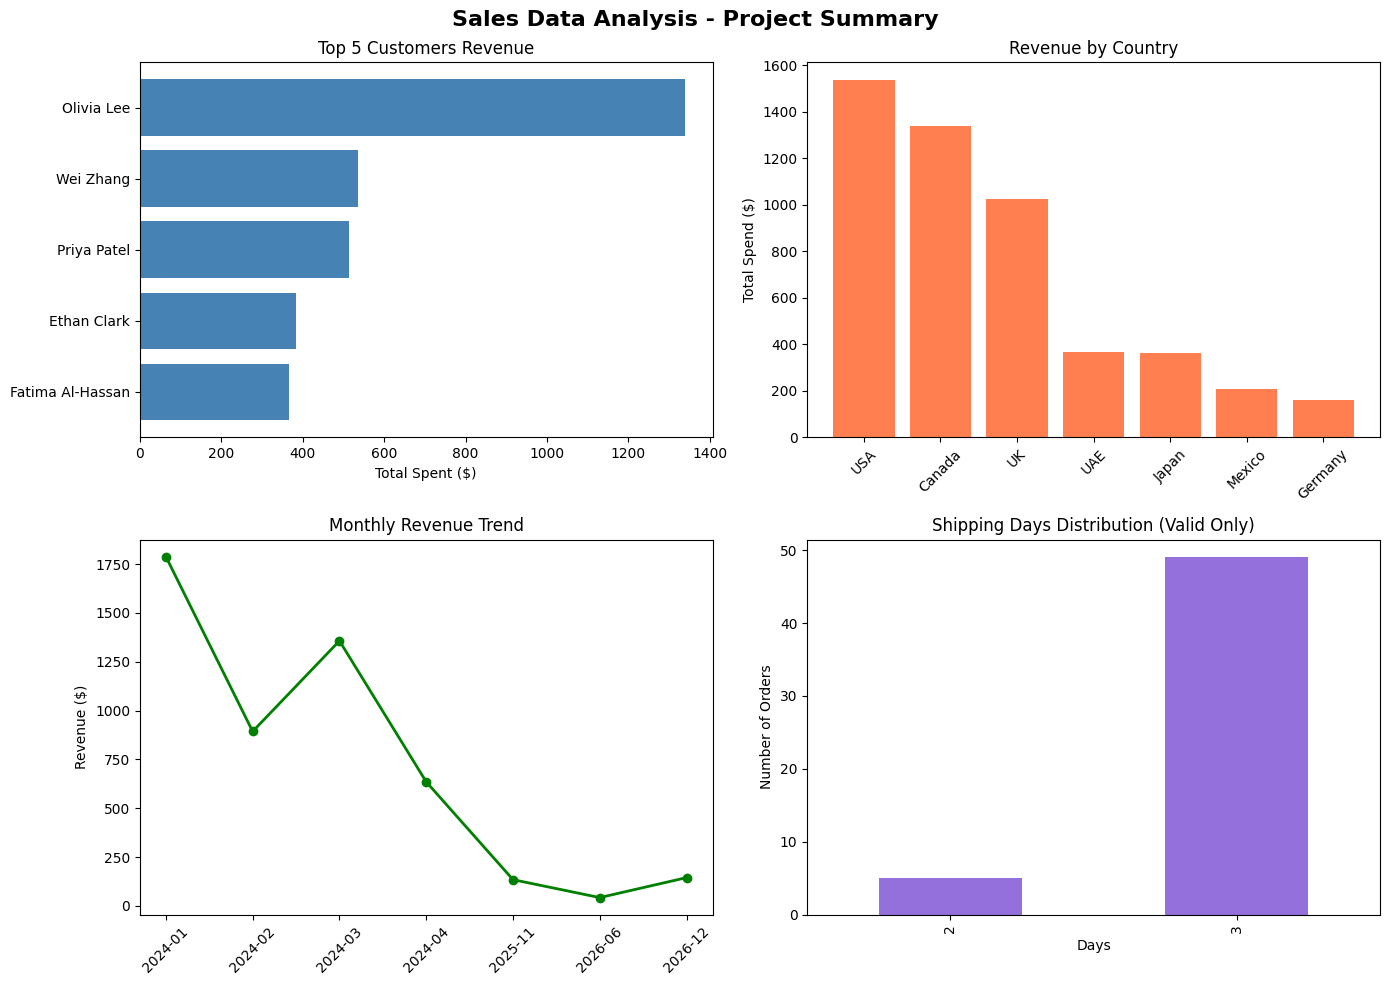

 Charts saved as sales_analysis_charts.png


In [147]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle ('Sales Data Analysis - Project Summary', fontsize = 16, fontweight = 'bold')

# --- Chart 1 : Top 5 Customers -----
axes[0, 0].barh(top_customers['Customer'],
                top_customers['Total Spent'], color='steelblue')
axes[0, 0].set_title('Top 5 Customers Revenue')
axes[0, 0].set_xlabel('Total Spent ($)')
axes[0, 0].invert_yaxis()

# --- Chart 2 : Revenue by Country -------
axes[0, 1].bar(country_revenue['Country'],
                country_revenue['Total Spent'], color = 'coral')
axes[0, 1].set_title('Revenue by Country')
axes[0, 1].set_ylabel('Total Spend ($)')
axes[0, 1].tick_params(axis='x', rotation = 45)

# --- Chart 3 : Monthly Trend --------
month_sorted = month_revenue.sort_values('Month')
axes[1, 0].plot(month_sorted['Month'].astype(str),
                month_sorted['Total Revenue'],
                marker='o', color='green', linewidth=2)
axes[1, 0].set_title('Monthly Revenue Trend')
axes[1, 0].set_ylabel('Revenue ($)')
axes[1, 0].tick_params(axis='x', rotation=45)

# --- Chart 4 : Shipping Days Distribution ------
valid_shipments['ship_days'].value_counts().sort_index().plot(kind='bar',
                                                              ax=axes[1,1],
                                                              color = 'mediumpurple')
axes[1, 1].set_title("Shipping Days Distribution (Valid Only)")
axes[1, 1].set_xlabel('Days')
axes[1, 1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.savefig('sales_analysis_charts.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Charts saved as sales_analysis_charts.png')